# Risk Analysis of Portfolio

In [59]:
# standard packages
import datetime
import math
import os
from typing import List

# open source packages
import matplotlib.pyplot as plt
import pandas as pd


In [60]:
def drawdown(rtrns: List[float], type: str) -> pd.DataFrame:
    """Calculate the drawdown of a return series.

    Args:
        rtrns (List[float]): a time series of returns.
        type (str): return type, 'simple' or 'log'.
    Returns:
        drawdown (pd.DataFrame): a dataframe of 'cum_rtrn', 'max_cum_rtrn', and 'drawdown'.
    """
    if rtrns is None or not isinstance(rtrns, list) or len(rtrns) == 0:
        raise ValueError("input returns are not valid")

    if type is None or not isinstance(type, str) or type not in ('simple', 'log'):
        raise ValueError("input return type is not valid")

    cum_rtrns = [0]
    curr_cum_rtrn = cum_rtrns[-1]
    max_cum_rtrns = [0]
    curr_max_cum_rtrn = max_cum_rtrns[-1]

    for i in range(len(rtrns)):
        if type == 'log':
            curr_cum_rtrn = curr_cum_rtrn + rtrns[i]
        elif type == 'simple':
            curr_cum_rtrn = (curr_cum_rtrn + 1) * (rtrns[i] + 1) - 1
        
        cum_rtrns.append(curr_cum_rtrn)
            
        if curr_max_cum_rtrn < curr_cum_rtrn:
            curr_max_cum_rtrn = curr_cum_rtrn
        
        max_cum_rtrns.append(curr_max_cum_rtrn)

    drawdown = pd.DataFrame({'cum_rtrn': cum_rtrns, 'max_cum_rtrn': max_cum_rtrns})
    drawdown['drawdown'] = drawdown['max_cum_rtrn'] - drawdown['cum_rtrn']

    return drawdown

In [61]:
data_dir = os.path.join(os.getcwd(), "test", "test_data", "etf")
print(data_dir)

C:\Users\zypub\PycharmProjects\sport\test\test_data\etf


            cum_rtrn  max_cum_rtrn  drawdown
DATE                                        
2024-02-12  0.000000      0.000000  0.000000
2024-02-13 -0.013869      0.000000  0.013869
2024-02-14 -0.004948      0.000000  0.004948
2024-02-15  0.001894      0.001894  0.000000
2024-02-16 -0.003107      0.001894  0.005002


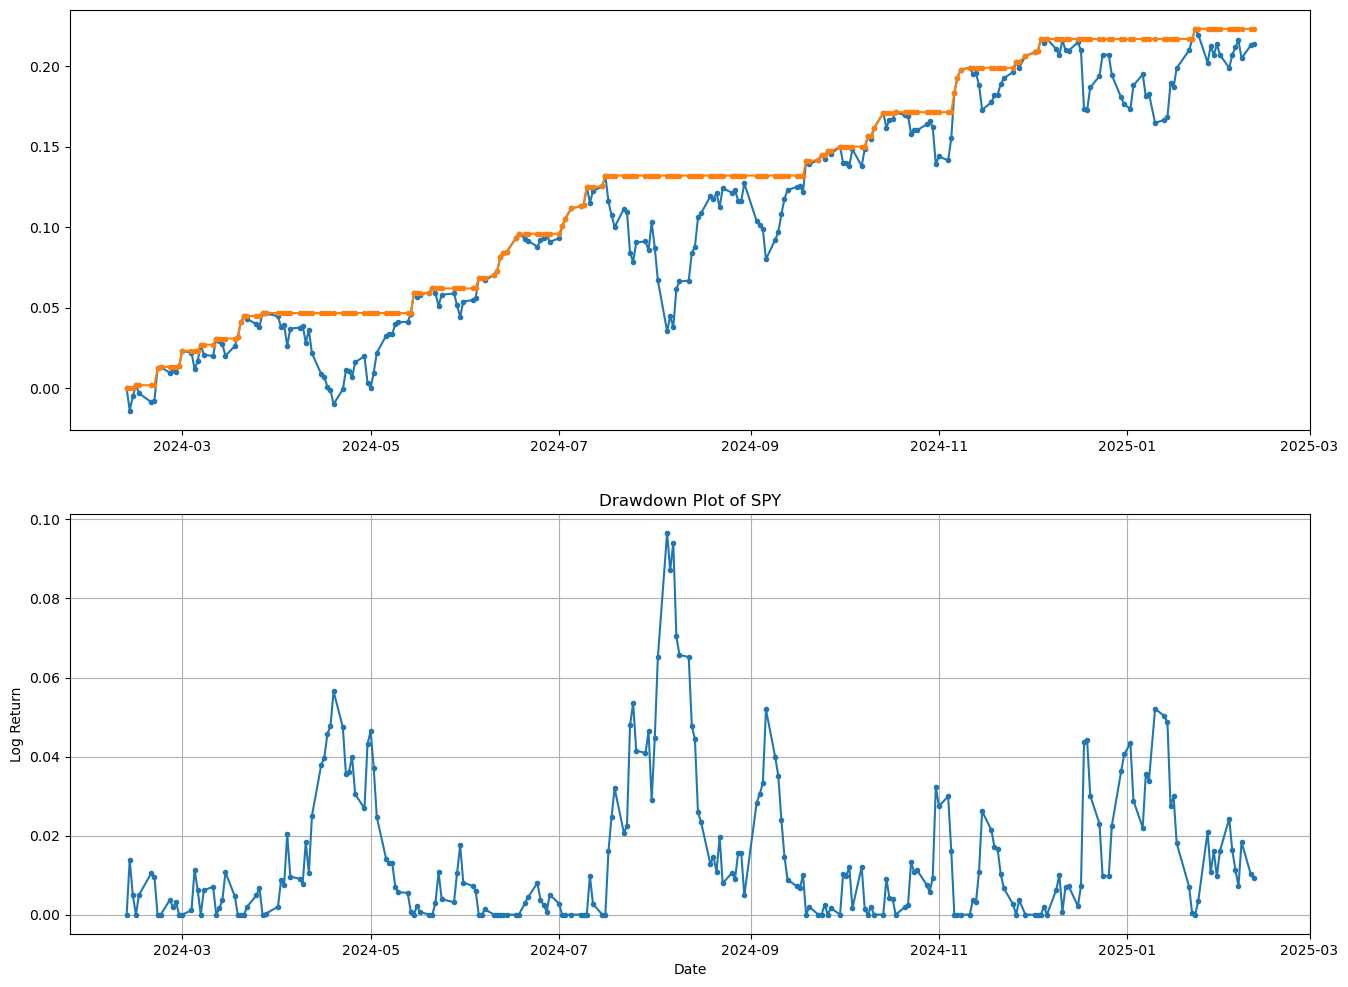

In [63]:
ticker = "SPY"

data = pd.read_csv(os.path.join(data_dir, f"""{ticker}.csv"""))
data['DATE'] = [datetime.datetime.strptime(x, "%Y-%m-%d").date() for x in data['DATE']]

prices = data['CLOSE'].to_list()
rtrns = [math.log(prices[i]) - math.log(prices[i - 1]) for i in range(1, len(prices))] 

dd = drawdown(rtrns=rtrns, type='simple')
dd.index = data['DATE']
print(dd.head())

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16,12))

axes[0].plot(dd.index, dd['cum_rtrn'], marker='.', linestyle='-')
axes[0].plot(dd.index, dd['max_cum_rtrn'], marker='.', linestyle='-')

axes[1].plot(dd.index, dd['drawdown'], marker='.', linestyle='-')

plt.title(f"""Drawdown Plot of {ticker}""")
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(True)

plt.show()